In [366]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from hmmlearn import _hmmc
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
import os


## Description

- Goal: implement MVO to determine optimal portfolio weights with state-conditional asset returns and covariance matrix
- Methodology:
  - Step 1: Use 13 macroeconomic indicators to classify states (number of states initially set to be 2)
  - Step 2: Once states are classified (according to sorted probabilities), estimate the mean and the covariance matrix (historical or more advanced methods, especially for the covariance matrix)
  - Step 3: Implement MVO for each of the state to determine optimal portfolio weights (for three assets: equity, gold and bond)
  - Step 4: Compare with static portfolios and backtest on historical test data

- Theoretical framework for Step 1: Two related hidden models
  - Plain vanilla HMM where conditional on the states which are assumed to follow a Markov chain, the observables are iid (Gaussian, for e.g.)
  - Markov Switching model (MSM): Even conditional on the states, the observables are allowed to exhibit serial correlation (for e.g., follow an AR(1))

In this notebook, we will be implementing Steps 1-4 for the HMM model using the `hmmlearn` package.

## Data prepration

First we need to standardize macroeconomic indicators. This is essentially as series having vastly different scales might lead to poorly conditioned covariance matrix and the EM algorithm struggling to converge. We also need to split the data into train and test sets.

In [367]:
def prepare_macro_data(macro_df, train_end_idx: int=None):
    """
    Prepares macroeconomic data for HMM training and testing.

    Parameters
    ----------
    macro_df      : pd.DataFrame of shape (T, n) — raw macro indicators
    train_end_idx : int — last training index; if None, use all data
 
    Returns
    -------
    X_train  : (T_train, n) standardized training array
    X_test   : (T_test, n) standardized test array (or None)
    scaler   : fitted StandardScaler (needed for out-of-sample)
    dates_train, dates_test
    """

    values = macro_df.values.astype(float)
    dates = macro_df.index

    if train_end_idx is None:
        train_end_idx = len(values)

    X_raw_train = values[:train_end_idx]
    X_raw_test = values[train_end_idx:] if train_end_idx < len(values) else None 

    # Fit scaler only on training data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_raw_train)
    X_test = scaler.transform(X_raw_test) if X_raw_test is not None else None

    dates_train = dates[:train_end_idx]
    dates_test = dates[train_end_idx:] if train_end_idx < len(dates) else None

    return X_train, X_test, scaler, dates_train, dates_test

In [368]:
data_path = os.path.join("..", "data", "macro_clean.csv")
macro_df = pd.read_csv(data_path, index_col=0, parse_dates=True)
macro_df.head()

,industrial_production,real_person_income,unemployment_rate,initial_jobless_claims,cpi,oil_price,vix,credit_spread,yield_curve_slope,fed_funds_rate,consumer_sentiment,housing_starts,m2_money_supply
1990-02-28,0.766531,0.212161,-0.176815,0.086523,0.648227,-0.517277,0.338459,-0.860618,-1.015353,0.112648,-0.816259,-0.973845,-0.117535
1990-03-31,0.370694,-0.144198,-0.176815,-0.056857,0.933078,-0.577370,0.033559,-1.001067,-1.092009,0.277788,0.453545,-1.387900,-0.208114
1990-04-30,-0.367467,0.581797,0.366229,0.272514,0.056672,-0.934117,0.005227,-1.113426,-1.015353,-0.052492,0.645214,-0.410427,-0.175312
1990-05-31,0.182830,-0.439503,0.004200,-0.054564,-0.234552,-0.572546,-0.284832,-0.818483,-0.993451,-0.382773,-0.768342,-0.371336,-0.905236
1990-06-30,0.216754,-0.099147,-0.357829,0.083436,1.493735,-0.255118,-0.537116,-0.706123,-0.894894,0.663116,-0.528756,-0.371754,-0.084565


In [369]:
macro_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   industrial_production   431 non-null    float64
 1   real_person_income      431 non-null    float64
 2   unemployment_rate       431 non-null    float64
 3   initial_jobless_claims  431 non-null    float64
 4   cpi                     431 non-null    float64
 5   oil_price               431 non-null    float64
 6   vix                     431 non-null    float64
 7   credit_spread           431 non-null    float64
 8   yield_curve_slope       431 non-null    float64
 9   fed_funds_rate          431 non-null    float64
 10  consumer_sentiment      431 non-null    float64
 11  housing_starts          431 non-null    float64
 12  m2_money_supply         431 non-null    float64
dtypes: float64(13)
memory usage: 47.1 KB


In [370]:
# train_length = int(0.8 * len(macro_df))
X_train, X_test, scaler, dates_train, dates_test = prepare_macro_data(macro_df)

In [371]:
X_train.shape, X_test.shape if X_test is not None else None

((431, 13), None)

## Model fitting

We will now fit an HMM to the standardized train data.

In [372]:
def fit_hmm(
        X_train: np.ndarray,
        K: int = 2,
        n_iter: int = 200,
        n_restarts: int = 10,
        tol: float = 1e-6, 
        random_state: int = 42
) -> GaussianHMM:
    """
    Fits a Gaussian HMM to the training data.

    Parameters
    ----------
    X_train      : (T_train, n) standardized training array
    K            : int — number of hidden states (regimes)
    n_iter       : int — max EM iterations per restart
    n_restarts   : int — number of random restarts for best model (avoid getting stuck in local optima)
    tol          : float — convergence threshold on log-likelihood improvement
    random_state : int — random seed for reproducibility (+1 per restart)

    Returns
    -------
    best_model : fitted GaussianHMM with highest log-likelihood
    """
    
    best_model = None
    best_loglik = -np.inf

    for i in range(n_restarts):
        model = GaussianHMM(
            n_components = K, 
            covariance_type = 'full', 
            n_iter = n_iter, 
            tol = tol,
            init_params = 'stmc',  # initialize startprob, transmat, means, covars
            random_state = random_state + i
        )
        # Run Baum-Welch EM algorithm to fit the model
        try:
            model.fit(X_train)
            loglik = model.score(X_train)

            if loglik > best_loglik:
                best_loglik = loglik
                best_model = model
        except Exception as e:
            # Occassionally EM can fail to converge or encounter numerical issues; we catch and move on
            print(f"Restart {i} failed: {e}")
            continue
    print(f"Best log-likelihood (per sample): {best_loglik:.4f}")
    return best_model

In [373]:
model = fit_hmm(X_train, K=2, n_iter=200, n_restarts=10, tol=1e-6, random_state=42)

Best log-likelihood (per sample): -5691.9189


In [374]:
model.means_.shape

(2, 13)

In [375]:
model.covars_.shape

(2, 13, 13)

## Extracting results

### Smoothed probabilities


In [376]:
def get_smoothed_probs(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """ 
    Computes smoothed state probabilities for each time point.
    Parameters
    ----------
    model : The trained Gaussian HMM.
    X     : np.ndarray of input data.

    Returns
    -------
    (K, T) np.ndarray of smoothed state probabilities.
    """
    return model.predict_proba(X).T

In [377]:
smoothed_probs_train = get_smoothed_probs(model, X_train)
smoothed_probs_train.shape

(2, 431)

In [378]:
# check if smoothed probabilities sum to 1 at each time point
smoothed_sums = smoothed_probs_train.sum(axis=0)
np.allclose(smoothed_sums, 1.0)

True

In [379]:
pd.DataFrame(smoothed_probs_train.T, index=dates_train, columns=[f"State {i}" for i in range(model.n_components)]).head()

,State 0,State 1
1990-02-28,1.0,1.684182e-295
1990-03-31,1.0,1.368005e-08
1990-04-30,1.0,1.240050e-07
1990-05-31,1.0,2.777758e-09
1990-06-30,1.0,1.244286e-08


### Filtered probabilities

In [380]:
def get_filtered_probs(model, X):
    """
    Computes filtered state probabilities: P(S_t=k | y_{1:t})
    Parameters
    ----------
    model : The trained Gaussian HMM.
    X     : np.ndarray of input data.

    Returns
    -------
    (K, T) np.ndarray of filtered state probabilities.
    """
    T = X.shape[0]
    K = model.n_components

    log_emit = model._compute_log_likelihood(X)   # (T,K)
    emit = np.exp(log_emit)

    alpha = np.zeros((T, K))

    # t=0
    alpha[0] = model.startprob_ * emit[0]
    alpha[0] /= alpha[0].sum()

    # recursion
    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ model.transmat_) * emit[t]
        s = alpha[t].sum()
        if s > 0:
            alpha[t] /= s
        else:
            alpha[t] = np.ones(K) / K

    return alpha.T

In [381]:
filtered_probs_train = get_filtered_probs(model, X_train)
filtered_probs_train.shape

(2, 431)

In [382]:
# check that filtered probabilities sum to 1 at each time point
filtered_sums = filtered_probs_train.sum(axis=0)
np.allclose(filtered_sums, 1.0)

True

In [383]:
pd.DataFrame(filtered_probs_train.T, index=dates_train, columns=[f"State {i}" for i in range(model.n_components)]).head()

,State 0,State 1
1990-02-28,1.0,5.639649e-295
1990-03-31,1.0,4.580857e-08
1990-04-30,1.0,4.152432e-07
1990-05-31,1.0,9.301596e-09
1990-06-30,1.0,4.166617e-08


### Hidden states (most likely sequence)

In [384]:
states_sequence = model.predict(X_train)
states_sequence.shape

(431,)

In [385]:
# unique states in sequence and their counts
np.unique(states_sequence, return_counts=True)

(array([0, 1]), array([394,  37]))

In [386]:
states_sequence_series = pd.Series(states_sequence, index=dates_train, name="HMM State")
states_sequence_series.value_counts()

HMM State
0    394
1     37
Name: count, dtype: int64

In [387]:
states_sequence_series[states_sequence_series == 1].index

DatetimeIndex(['1992-07-31', '1992-08-31', '1992-12-31', '1993-01-31',
               '1993-12-31', '1994-01-31', '2001-09-30', '2001-10-31',
               '2004-12-31', '2005-01-31', '2008-09-30', '2008-10-31',
               '2008-11-30', '2008-12-31', '2009-01-31', '2009-02-28',
               '2009-03-31', '2009-04-30', '2009-05-31', '2011-01-31',
               '2012-12-31', '2013-01-31', '2020-03-31', '2020-04-30',
               '2020-05-31', '2020-06-30', '2020-07-31', '2020-08-31',
               '2020-09-30', '2020-10-31', '2021-02-28', '2021-03-31',
               '2021-04-30', '2021-05-31', '2021-09-30', '2021-10-31',
               '2021-11-30'],
              dtype='datetime64[us]', freq=None)

In [388]:
len(dates_train[dates_train.year < 2020]) / len(dates_train)

0.8329466357308585

In [389]:
dates_train[int(0.8 * len(dates_train))]

Timestamp('2018-10-31 00:00:00')

### Transition matrix

In [390]:
# transition matrix
pd.DataFrame(model.transmat_, 
             columns=[f"State {i}" for i in range(model.n_components)], 
             index=[f"State {i}" for i in range(model.n_components)]
            )

,State 0,State 1
State 0,0.972742,0.027258
State 1,0.290492,0.709508


Many empirical studies suggest that the expansionary state is more persistent than recessionary one. In particular, recessions tend to be short-lived on average compared to expansionary periods.

In [391]:
print(f"Average duration in each state (expected number of consecutive months):")
for i, persistent_prob in enumerate(model.transmat_.diagonal()):
    print(f"State {i}: {1 / (1 - persistent_prob):.2f} months")

Average duration in each state (expected number of consecutive months):
State 0: 36.69 months
State 1: 3.44 months


This suggests that state 0 corresponds to the expansionary phase and state 1 the recessionary phase of the business cycle. The estimated conditional means and covariance matrices below further confirm this conclusion.

### Conditional means and covariance matrices

In [392]:
# conditional means
pd.DataFrame(model.means_, 
             columns=macro_df.columns, 
             index=["State 0 (Expansion)", "State 1 (Recession)"]
            ).T

,State 0 (Expansion),State 1 (Recession)
industrial_production,0.048157,-0.514527
real_person_income,0.027426,-0.293027
unemployment_rate,-0.024822,0.265207
initial_jobless_claims,-0.011718,0.125198
cpi,0.039257,-0.419432
oil_price,0.020371,-0.217652
vix,-0.103440,1.105177
credit_spread,-0.108350,1.157643
yield_curve_slope,-0.049909,0.533237
fed_funds_rate,0.059855,-0.639510


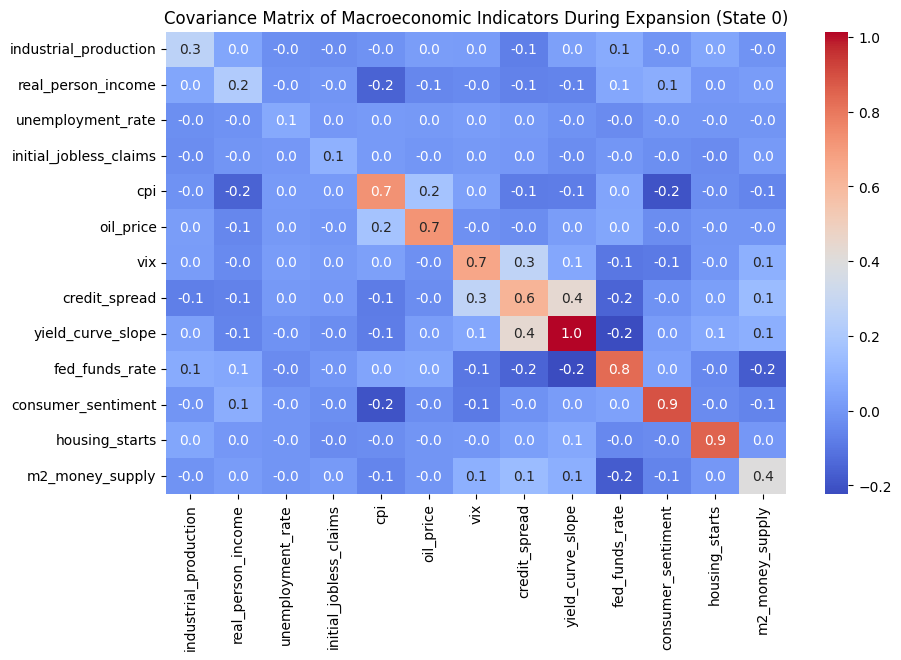

In [393]:
plt.figure(figsize=(10, 6))
sns.heatmap(model.covars_[0], annot=True, fmt=".1f", cmap="coolwarm",
            xticklabels=macro_df.columns, yticklabels=macro_df.columns
)
plt.title("Covariance Matrix of Macroeconomic Indicators During Expansion (State 0)")
plt.show()



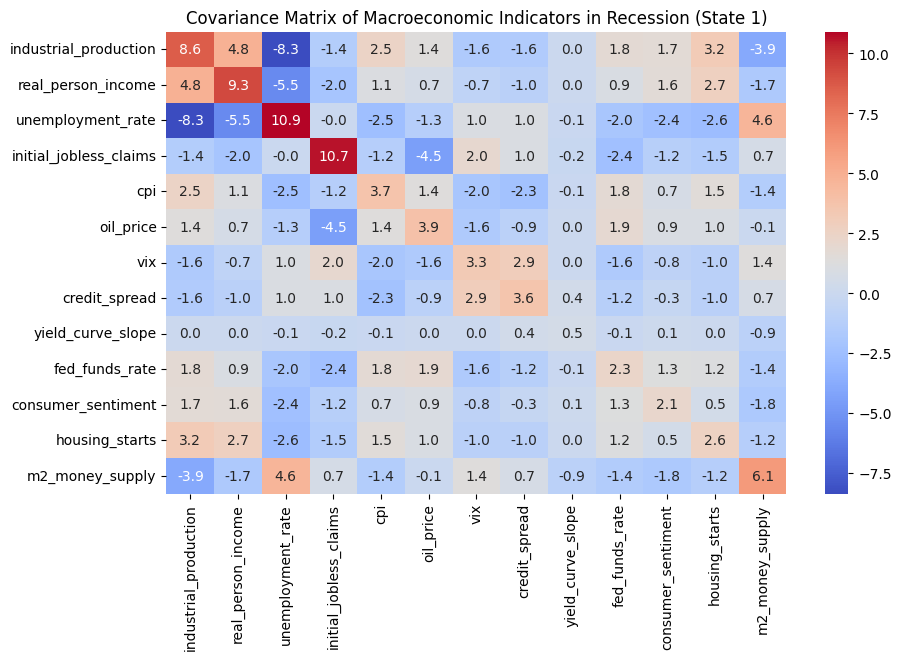

In [394]:
plt.figure(figsize=(10, 6))
sns.heatmap(model.covars_[1], annot=True, fmt=".1f", cmap="coolwarm",
            xticklabels=macro_df.columns, yticklabels=macro_df.columns
)
plt.title("Covariance Matrix of Macroeconomic Indicators in Recession (State 1)")
plt.show()



## Plotting results

In [395]:
def plot_hmm_states(dates, states, title="HMM Regime States"):
    """
    Plots the inferred HMM states over time.

    Parameters
    ----------
    dates  : array-like of datetime — time index for x-axis
    states : array-like of int — inferred state sequence (0 to K-1)
    title  : str — plot title
    """
    plt.figure(figsize=(12, 4))
    plt.plot(dates, states, drawstyle='steps-post', marker='o')
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Inferred State")
    plt.yticks(np.unique(states))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_hmm_state_probs(dates, probs, title="HMM State Probabilities"):
    """
    Plots the HMM state probabilities over time.

    Parameters
    ----------
    dates : array-like of datetime — time index for x-axis
    probs : (K, T) np.ndarray of state probabilities
    title : str — plot title
    """
    plt.figure(figsize=(12, 4))
    probs_df = pd.DataFrame(probs.T, index=dates, columns=[f"State {i}" for i in range(probs.shape[0])])
    probs_df.plot(ax=plt.gca())
    plt.xlabel('Date')
    plt.ylabel('Probability')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

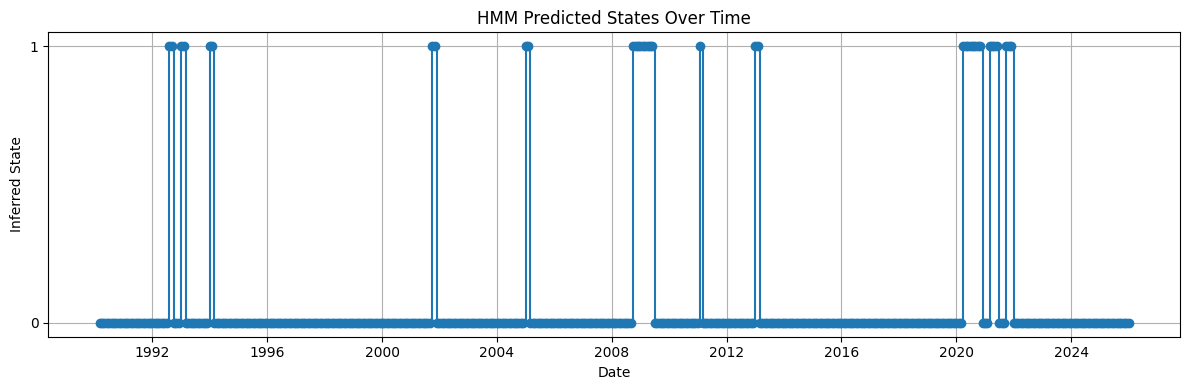

In [396]:
plot_hmm_states(dates_train, states_sequence, title="HMM Predicted States Over Time")

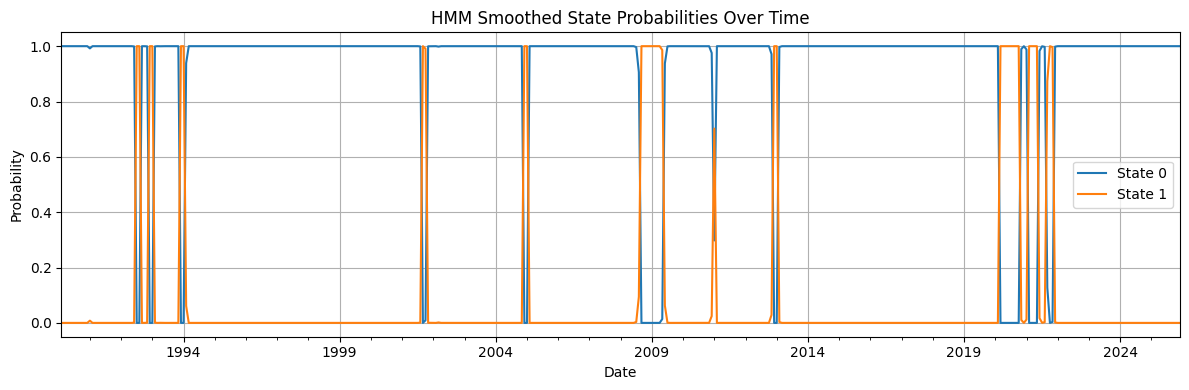

In [397]:
plot_hmm_state_probs(dates_train, smoothed_probs_train, title="HMM Smoothed State Probabilities Over Time")

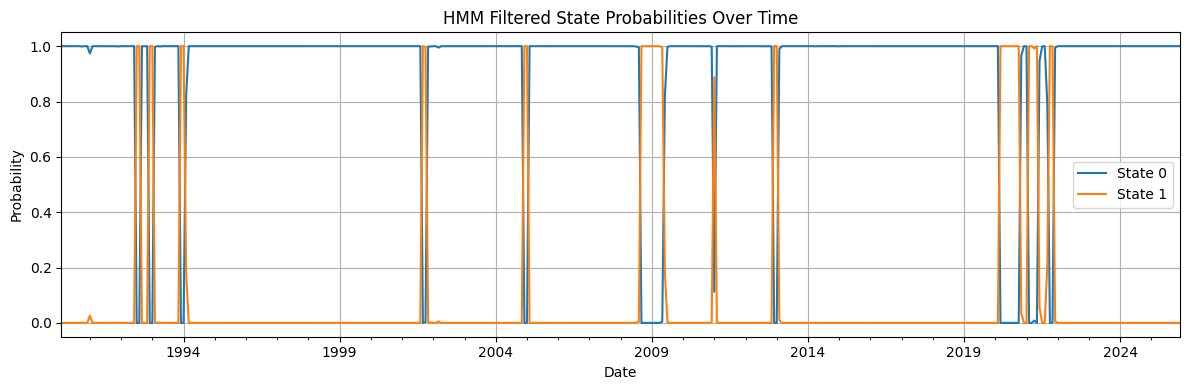

In [398]:
plot_hmm_state_probs(dates_train, filtered_probs_train, title="HMM Filtered State Probabilities Over Time")

We add the inferred states to macroeconomic dataset as well as the market dataset (consisting of three index series: equity, bond and gold) and make a few plots to illustrate along with the series.

In [399]:
macro_df_expanded = macro_df.copy()
macro_df_expanded["HMM State"] = states_sequence
# macro_df_expanded.head()

In [400]:
macro_df_expanded.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   industrial_production   431 non-null    float64
 1   real_person_income      431 non-null    float64
 2   unemployment_rate       431 non-null    float64
 3   initial_jobless_claims  431 non-null    float64
 4   cpi                     431 non-null    float64
 5   oil_price               431 non-null    float64
 6   vix                     431 non-null    float64
 7   credit_spread           431 non-null    float64
 8   yield_curve_slope       431 non-null    float64
 9   fed_funds_rate          431 non-null    float64
 10  consumer_sentiment      431 non-null    float64
 11  housing_starts          431 non-null    float64
 12  m2_money_supply         431 non-null    float64
 13  HMM State               431 non-null    int64  
dtypes: float64(13), int64(1)
memory us

In [401]:
asset_df = pd.read_csv(os.path.join("..", "data", "market_clean.csv"), index_col=0, parse_dates=True)
# asset_df.head()
asset_df.columns = ['Equity', 'Bonds', 'Gold']
asset_df_expanded = asset_df.copy()
asset_df_expanded["HMM State"] = macro_df_expanded["HMM State"]

In [402]:
asset_df_expanded.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Equity     431 non-null    float64
 1   Bonds      431 non-null    float64
 2   Gold       431 non-null    float64
 3   HMM State  431 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 16.8 KB


In [403]:
asset_df_expanded.describe()

,Equity,Bonds,Gold,HMM State
count,431.000000,431.000000,431.000000,431.000000
mean,0.009680,0.006387,0.006194,0.085847
std,0.042492,0.031691,0.036499,0.280463
min,-0.167924,-0.089336,-0.117325,0.000000
25%,-0.015831,-0.013533,-0.014813,0.000000
50%,0.013700,0.006494,0.000731,0.000000
75%,0.036674,0.023550,0.025401,0.000000
max,0.128138,0.120741,0.173680,1.000000


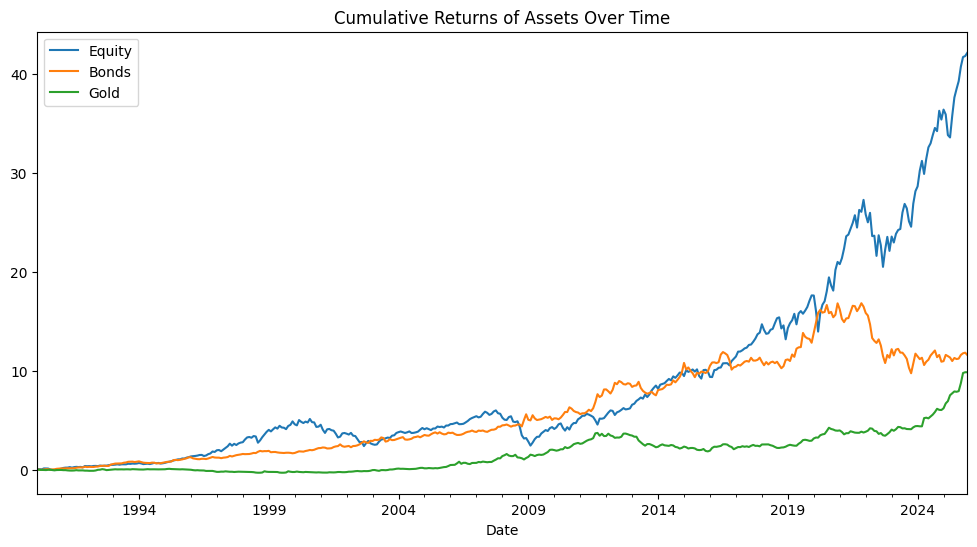

In [404]:
asset_cumret = (1 + asset_df).cumprod() - 1
asset_cumret.plot(figsize=(12, 6), title="Cumulative Returns of Assets Over Time")
plt.show()

In [405]:

# --- style constants ---------------------------------------------------------
COLOR_0   = '#2166ac'   # blue  — expansion (state 0)
COLOR_1   = '#d6312b'   # red   — recession  (state 1)
SHADE_COL = "#5E5D5D"   # gray  — state-1 shading
SHADE_A   = 0.4        # shading alpha
LW        = 1.4         # line width


def _contiguous_blocks(mask):
    """
    Return (start, end) index pairs for contiguous True runs in a boolean mask.
    Used to draw one axvspan per recession episode rather than per observation.
    """
    blocks = []
    in_block = False
    for i, val in enumerate(mask):
        if val and not in_block:
            start = i
            in_block = True
        elif not val and in_block:
            blocks.append((start, i - 1))
            in_block = False
    if in_block:
        blocks.append((start, len(mask) - 1))
    return blocks


def plot_series_colored(df, series_name, state_col="HMM State", ax=None):
    """
    Plot series with line color switching by regime.

    Parameters
    ----------
    df        : pd.DataFrame with DatetimeIndex, series and state columns
    series_name : name of the series column to plot
    state_col : name of the state column (values 0 or 1)
    ax        : matplotlib Axes; if None a new figure is created
    Returns
    -------
    ax : the matplotlib Axes with the plot
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    dates  = df.index
    series = df[series_name].values
    states = df[state_col].values
    colors = [COLOR_0, COLOR_1]

    # Find where the state changes — these are segment boundaries
    change_idx = np.where(np.diff(states) != 0)[0] + 1          # first idx of new state
    seg_starts = np.concatenate([[0], change_idx])
    seg_ends   = np.concatenate([change_idx, [len(states)]])     # exclusive end

    for s, e in zip(seg_starts, seg_ends):
        # Extend segment by one point to the right so adjacent segments
        # share an endpoint — eliminates gaps at color transitions
        end_ext = min(e + 1, len(states))
        ax.plot(dates[s:end_ext], series[s:end_ext],
                color=colors[states[s]], linewidth=LW)

    # Legend
    legend_elements = [
        Line2D([0], [0], color=COLOR_0, lw=2, label='State 0 — Expansion'),
        Line2D([0], [0], color=COLOR_1, lw=2, label='State 1 — Recession'),
    ]
    ax.legend(handles=legend_elements, loc='best', framealpha=0.9)

    return ax


def plot_series_shaded(df, series_name, state_col="HMM State", ax=None):
    """
    Plot 2 — series in black with state-1 periods shaded gray.

    Technique: draw the full series line first, then overlay one axvspan
    per contiguous state-1 episode. Using contiguous blocks (rather than
    one span per observation) keeps the number of patches small and renders
    cleanly even at high time resolution.

    Parameters
    ----------
    df        : pd.DataFrame with DatetimeIndex, series and state columns
    series_name : name of the series column to plot
    state_col : name of the state column (values 0 or 1)
    ax        : matplotlib Axes; if None a new figure is created
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    dates  = df.index
    series = df[series_name].values
    states = df[state_col].values

    # Full series
    ax.plot(dates, series, color='#222222', linewidth=LW, zorder=3)

    # Shade each contiguous state-1 block
    # axvspan uses data coordinates — pass actual dates, not integer indices
    for start_i, end_i in _contiguous_blocks(states == 1):
        ax.axvspan(dates[start_i], dates[end_i],
                   color=SHADE_COL, alpha=SHADE_A, zorder=2)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Line2D([0], [0], color='#222222', lw=2, label=series_name),
        Patch(facecolor=SHADE_COL, alpha=SHADE_A, label='State 1 — Recession'),
    ]
    ax.legend(handles=legend_elements, loc='best', framealpha=0.9)

    return ax


<Axes: >

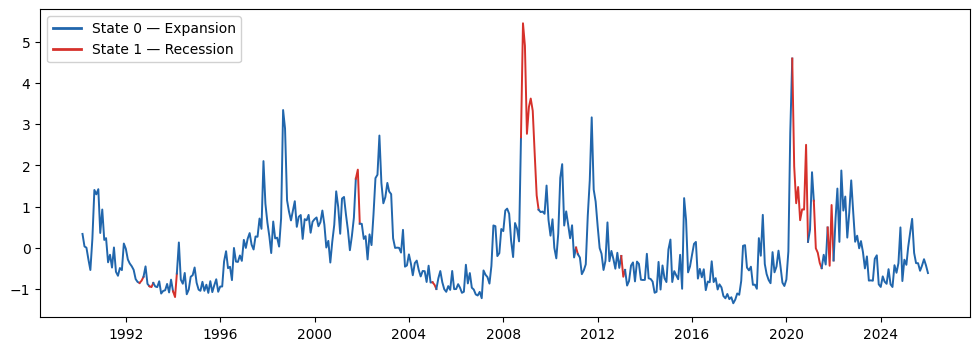

In [406]:
plot_series_colored(macro_df_expanded, series_name='vix', state_col='HMM State')

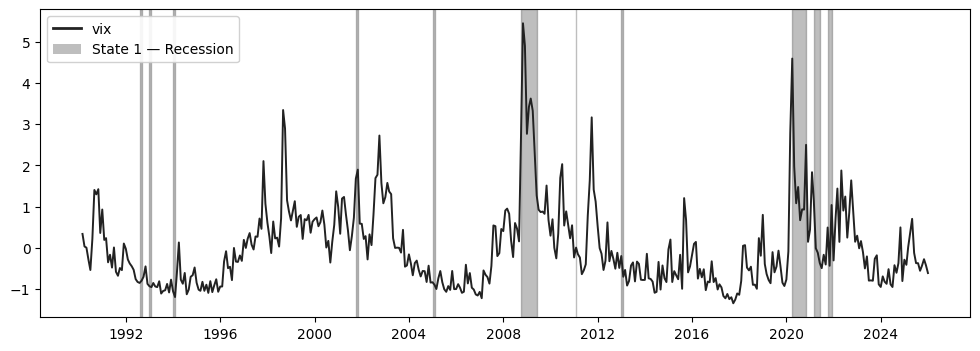

In [407]:
plot_series_shaded(macro_df_expanded, series_name='vix', state_col='HMM State')
plt.show()

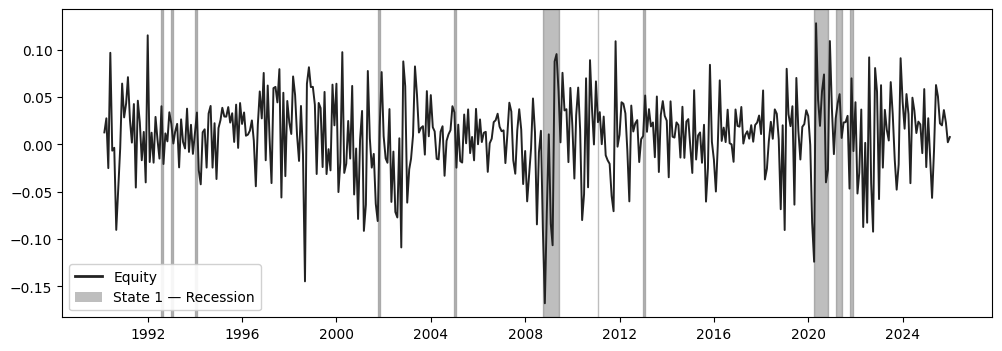

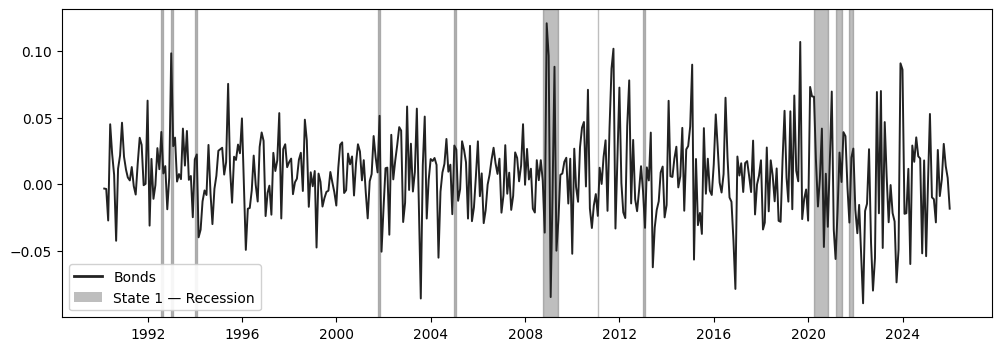

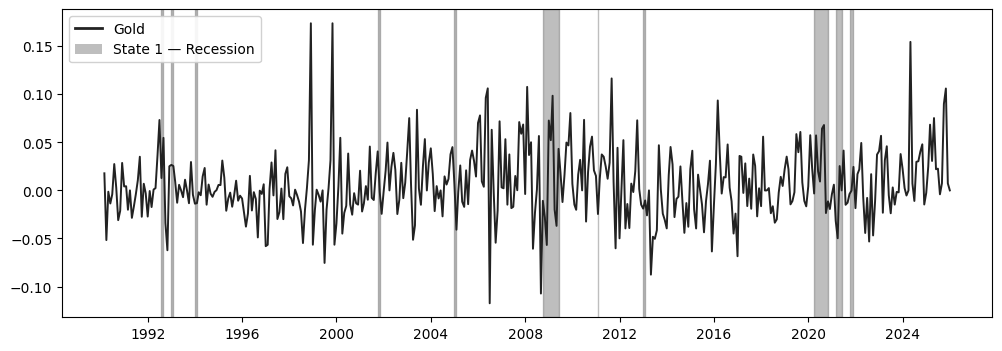

In [408]:

for col in asset_df.columns:
    plot_series_shaded(asset_df_expanded, series_name=col, state_col="HMM State", ax=None)

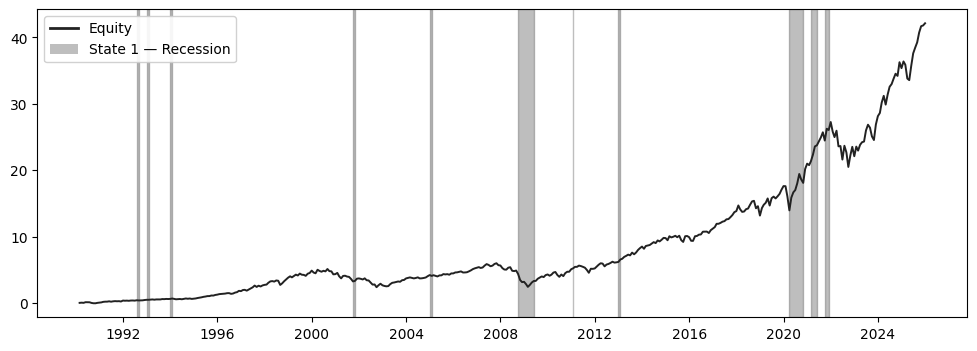

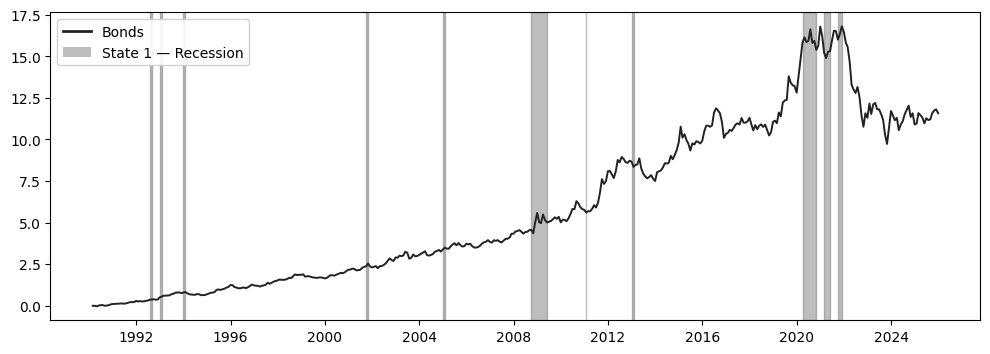

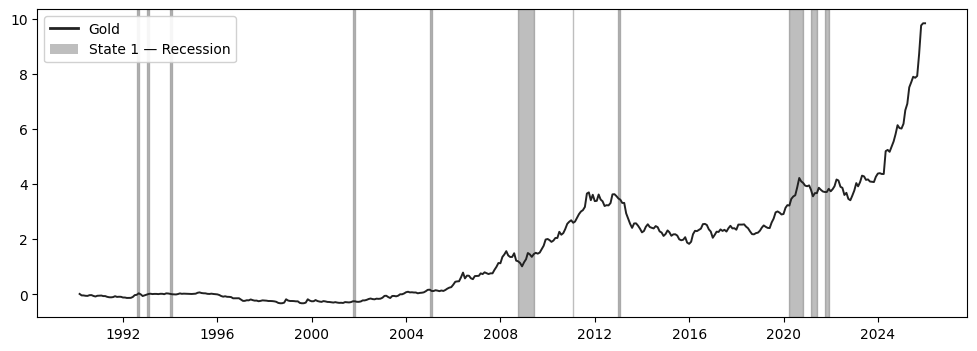

In [409]:
asset_cumret_expanded = asset_cumret.copy()
asset_cumret_expanded["HMM State"] = macro_df_expanded["HMM State"]
for col in asset_cumret.columns:
    plot_series_shaded(asset_cumret_expanded, series_name=col, state_col="HMM State", ax=None)
    

## Portfolio optimization

We now proceed to determine optimal portfolio weights which depend on the state-dependent mean vector and covariance matrix.

We first split the data into a train and test set. Then covariance matrices will be estimated using the train data and then be used to implement MVO to determine optimal weights.

### Data splitting

In [410]:
def train_test_split(df, train_size=0.8):
    """
    Splits a DataFrame into training and test sets based on a specified training size.

    Parameters
    ----------
    df         : pd.DataFrame with DatetimeIndex
    train_size  : float (0, 1) — proportion of data to use for training

    Returns
    -------
    df_train : pd.DataFrame for training
    df_test  : pd.DataFrame for testing
    """
    split_idx = int(len(df) * train_size)
    df_train = df.iloc[:split_idx]
    df_test = df.iloc[split_idx:]
    return df_train, df_test


In [411]:
market_train, market_test = train_test_split(asset_df_expanded)
print("Last train date:", market_train.index[-1]) 
print("First test date:", market_test.index[0])

Last train date: 2018-09-30 00:00:00
First test date: 2018-10-31 00:00:00


### Estimation of state-conditional covariance via Ledoit-Wolf's shrinkage

Since the number of observations in one of the states is small (fewer than 10 percent of the time series length), we will use Ledoit-Wolf's shrinkage method to estimate the mean vectors and the covariance matrices.

In [412]:
def estimate_regime_moments(df_train, asset_cols, state_col='state'):
    """
    Estimate state-conditional mean and covariance for each regime.

    Parameters
    ----------
    df_train   : pd.DataFrame — training data with state and asset columns
    asset_cols : list of str  — asset return column names
    state_col  : str          — name of the state column
 
    Returns
    -------
    moments : dict with keys 0, 1 (one entry per regime), each containing:
        'mu'        : (n,)   sample mean return vector
        'sigma'     : (n, n) Ledoit-Wolf shrunk covariance matrix
        'sigma_raw' : (n, n) raw sample covariance (for comparison)
        'shrinkage' : float  Ledoit-Wolf shrinkage intensity α
        'n_obs'     : int    number of observations in this regime
    """
    moments = {}
    states  = sorted(df_train[state_col].unique())
 
    for k in states:
        # Extract returns for regime k
        mask = df_train[state_col] == k
        R_k  = df_train.loc[mask, asset_cols].values   # (T_k, n)
        T_k, n = R_k.shape
 
        # Sample mean — unaffected by shrinkage
        mu_k = R_k.mean(axis=0)                        # (n,)
 
        # Ledoit-Wolf shrunk covariance
        lw = LedoitWolf().fit(R_k)
        Sigma_lw  = lw.covariance_                     # (n, n)
        alpha     = lw.shrinkage_                      # scalar α
 
        # Raw sample covariance — keep for diagnostics
        Sigma_raw = np.cov(R_k, rowvar=False)          # (n, n)
 
        moments[k] = {
            'mu':        mu_k,
            'sigma':     Sigma_lw,
            'sigma_raw': Sigma_raw,
            'shrinkage': alpha,
            'n_obs':     T_k,
        }
 
        print(f"\n── Regime {k}  ({T_k} observations) ──")
        print(f"  Mean returns (annualized %):")
        for col, m in zip(asset_cols, mu_k * 12 * 100):    # monthly → annual
            print(f"    {col:<10}: {m:+.2f}%")
        print(f"  Ledoit-Wolf shrinkage α : {alpha:.4f}")
        print(f"  Shrunk covariance Σ^{k}:")
        print(_fmt_matrix(Sigma_lw, asset_cols))
        print(f"  Implied annual volatilities:")
        for col, v in zip(asset_cols, np.sqrt(np.diag(Sigma_lw) * 12) * 100):
            print(f"    {col:<10}: {v:.2f}%")
 
    return moments

def _fmt_matrix(M, labels):
    """Pretty-print a square matrix with row/column labels."""
    w = max(len(l) for l in labels) + 2
    header = ' ' * w + ''.join(f'{l:>{w}}' for l in labels)
    rows   = [header]
    for i, label in enumerate(labels):
        row = f'{label:>{w}}' + ''.join(f'{M[i,j]:>{w}.5f}' for j in range(len(labels)))
        rows.append(row)
    return '\n'.join(rows)

In [413]:
moments = estimate_regime_moments(market_train, 
                                  asset_cols=market_train.columns[:-1],  
                                  state_col="HMM State")



── Regime 0  (322 observations) ──
  Mean returns (annualized %):
    Equity    : +12.09%
    Bonds     : +8.31%
    Gold      : +4.58%
  Ledoit-Wolf shrinkage α : 0.1796
  Shrunk covariance Σ^0:
          Equity   Bonds    Gold
  Equity 0.00140-0.00013-0.00010
   Bonds-0.00013 0.00079 0.00012
    Gold-0.00010 0.00012 0.00130
  Implied annual volatilities:
    Equity    : 12.95%
    Bonds     : 9.71%
    Gold      : 12.48%

── Regime 1  (22 observations) ──
  Mean returns (annualized %):
    Equity    : -8.12%
    Bonds     : +20.11%
    Gold      : +8.54%
  Ledoit-Wolf shrinkage α : 0.9043
  Shrunk covariance Σ^1:
          Equity   Bonds    Gold
  Equity 0.00294 0.00006-0.00004
   Bonds 0.00006 0.00277-0.00002
    Gold-0.00004-0.00002 0.00267
  Implied annual volatilities:
    Equity    : 18.77%
    Bonds     : 18.22%
    Gold      : 17.90%


In [414]:
def shrinkage_diagnostics(moments, asset_cols):
    """
    Compare raw vs shrunk covariance to quantify the effect of Ledoit-Wolf.
    """
    print("\n── Difference between shrunk and raw covariance ──")
    for k, m in moments.items():
        diff = m['sigma'] - m['sigma_raw']
        print(f"\nRegime {k}  (α = {m['shrinkage']:.4f}):")
        print(_fmt_matrix(diff, asset_cols))

In [415]:
shrinkage_diagnostics(moments, asset_cols=market_train.columns[:-1])


── Difference between shrunk and raw covariance ──

Regime 0  (α = 0.1796):
          Equity   Bonds    Gold
  Equity-0.00006 0.00003 0.00002
   Bonds 0.00003 0.00008-0.00003
    Gold 0.00002-0.00003-0.00003

Regime 1  (α = 0.9043):
          Equity   Bonds    Gold
  Equity-0.00157-0.00057 0.00044
   Bonds-0.00057 0.00010 0.00017
    Gold 0.00044 0.00017 0.00107


### State-conditional optimal portfolios

Now we are ready to implement MVO to determine optimal portfolio weights.

In [416]:
"""
Regime-Conditional Mean-Variance Optimization
==============================================
Given state-conditional moments (μ^k, Σ^k) estimated from the training
data, this module solves a separate MVO problem for each regime k.

The optimizer returns:
  - Minimum variance portfolio (no return target)
  - Maximum Sharpe ratio portfolio
  - Efficient frontier (set of optimal portfolios across risk levels)

Library: cvxpy (pip install cvxpy)

Math notation:
  n       — number of assets
  w       — (n,) portfolio weight vector
  μ^k     — (n,) expected return vector for regime k
  Σ^k     — (n,n) covariance matrix for regime k
  rf      — risk-free rate (per period, same frequency as returns)
  γ       — risk aversion parameter
"""

import numpy as np
import cvxpy as cp
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass


# =============================================================================
# RESULT CONTAINER
# =============================================================================

@dataclass
class PortfolioResult:
    """
    Holds the output of a single MVO solve.

    Attributes
    ----------
    weights      : (n,) optimal weight vector
    exp_return   : float — w^T μ^k  (per period)
    volatility   : float — sqrt(w^T Σ^k w)  (per period)
    sharpe       : float — (exp_return - rf) / volatility
    regime       : int   — which regime this was solved for
    portfolio    : str   — label e.g. 'min_variance', 'max_sharpe'
    asset_names  : list  — asset labels for display
    """
    weights    : np.ndarray
    exp_return : float
    volatility : float
    sharpe     : float
    regime     : int
    portfolio  : str
    asset_names: list

    def summary(self):
        ann = 12    # monthly → annual scaling
        print(f"\n── {self.portfolio}  |  Regime {self.regime} ──")
        print(f"  Expected return (ann.) : {self.exp_return * ann * 100:+.2f}%")
        print(f"  Volatility     (ann.) : {self.volatility * np.sqrt(ann) * 100:.2f}%")
        print(f"  Sharpe ratio          : {self.sharpe * np.sqrt(ann):.4f}")
        print(f"  Weights:")
        for name, w in zip(self.asset_names, self.weights):
            print(f"    {name:<12}: {w:.4f}  ({w*100:.1f}%)")


# =============================================================================
# CORE SOLVER
# =============================================================================

def _solve_mvo(mu, Sigma, objective='min_variance',
               rf=0.0, gamma=3.0,
               long_only=True, max_weight=1.0):
    """
    Solve a single MVO problem using cvxpy.

    THREE OBJECTIVES
    ----------------

    1. 'min_variance'
       Minimize portfolio variance subject to full investment:
         min   w^T Σ w
         s.t.  1^T w = 1
               w >= 0  (if long_only)

       This is a pure Quadratic Program (QP). No return target is imposed —
       the result is the global minimum variance portfolio (GMV).
       cvxpy formulation: cp.Minimize(cp.quad_form(w, Sigma))

    2. 'max_sharpe'
       Maximize the Sharpe ratio:
         max   (w^T μ - rf) / sqrt(w^T Σ w)
         s.t.  1^T w = 1,  w >= 0

       This is NOT a convex problem as stated (ratio of linear to sqrt-quadratic).
       Standard trick (Cornuejols & Tütüncü 2006): substitute y = w / (w^T μ - rf)
       and κ = 1 / (w^T μ - rf), then solve:
         min   y^T Σ y
         s.t.  (μ - rf)^T y = 1
               1^T y = κ,  y >= 0,  κ >= 0
       and recover w = y / κ.  This is a QP and is convex.

    3. 'max_return' for a given risk aversion γ:
       Maximize the mean-variance utility:
         max   w^T μ - (γ/2) w^T Σ w
         s.t.  1^T w = 1,  w >= 0
       Equivalently: min  (γ/2) w^T Σ w - w^T μ

    CONSTRAINTS
    -----------
    - Full investment:  1^T w = 1  (weights sum to 1)
    - Long-only:        w >= 0     (no short selling)
    - Max weight:       w <= max_weight  (concentration limit, default 100%)

    Parameters
    ----------
    mu         : (n,) expected return vector
    Sigma      : (n, n) covariance matrix (positive definite)
    objective  : 'min_variance' | 'max_sharpe' | 'max_return'
    rf         : risk-free rate per period
    gamma      : risk aversion (only used for 'max_return')
    long_only  : bool — enforce w >= 0
    max_weight : float — upper bound per asset (default 1.0 = unconstrained)

    Returns
    -------
    w_opt : (n,) optimal weights, or equal-weight fallback if solve fails
    """
    n = len(mu)

    # Ensure Sigma is numpy array and symmetric
    Sigma = np.array(Sigma)
    Sigma = 0.5 * (Sigma + Sigma.T)

    # ── Min Variance ──────────────────────────────────────────────────────
    if objective == 'min_variance':
        w = cp.Variable(n)
        # cp.quad_form(w, Sigma) computes w^T Σ w
        prob = cp.Problem(
            cp.Minimize(cp.quad_form(w, Sigma)),
            _constraints(w, n, long_only, max_weight)
        )

    # ── Max Sharpe (Tobin separation via variable substitution) ───────────
    elif objective == 'max_sharpe':
        # Substitution: y = w/κ where κ = 1/(μ^T w - rf)
        # After substitution the problem becomes a QP in y
        y   = cp.Variable(n)        # y = w / (w^T(μ-rf))
        kap = cp.Variable()         # κ = 1  / (w^T(μ-rf))  — must be > 0

        excess_mu = mu - rf

        constraints = [
            excess_mu @ y == 1,     # normalization: (μ-rf)^T y = 1
            cp.sum(y) == kap,       # full investment after substitution
            kap >= 0,
        ]
        if long_only:
            constraints.append(y >= 0)
        if max_weight < 1.0:
            constraints.append(y <= max_weight * kap)

        prob = cp.Problem(cp.Minimize(cp.quad_form(y, Sigma)), constraints)
        prob.solve(solver=cp.CLARABEL)

        if prob.status in ('optimal', 'optimal_inaccurate') and kap.value > 1e-10:
            w_opt = y.value / kap.value
            w_opt = np.clip(w_opt, 0 if long_only else -np.inf, max_weight)
            w_opt /= w_opt.sum()
            return w_opt

        # Fallback: equal weight
        return np.ones(n) / n

    # ── Max Return (mean-variance utility) ───────────────────────────────
    elif objective == 'max_return':
        w = cp.Variable(n)
        # Maximise w^T μ - (γ/2) w^T Σ w
        # ≡ Minimise (γ/2) w^T Σ w - w^T μ
        prob = cp.Problem(
            cp.Minimize(0.5 * gamma * cp.quad_form(w, Sigma) - mu @ w),
            _constraints(w, n, long_only, max_weight)
        )

    else:
        raise ValueError(f"Unknown objective '{objective}'")

    # Solve
    prob.solve(solver=cp.CLARABEL)

    if prob.status in ('optimal', 'optimal_inaccurate') and w.value is not None:
        w_opt = np.clip(w.value, 0 if long_only else -np.inf, max_weight)
        w_opt /= w_opt.sum()   # renormalize for numerical precision
        return w_opt

    # Fallback: equal weight if solver fails
    print(f"  Warning: solver status '{prob.status}' — returning equal weights.")
    return np.ones(n) / n


def _constraints(w, n, long_only, max_weight):
    """Build the standard MVO constraint list."""
    cons = [cp.sum(w) == 1]          # full investment
    if long_only:
        cons.append(w >= 0)          # no short selling
    if max_weight < 1.0:
        cons.append(w <= max_weight) # concentration limit
    return cons


# =============================================================================
# REGIME-CONDITIONAL MVO
# =============================================================================

def optimize_regimes(moments, asset_names,
                     rf=0.0, long_only=True, max_weight=1.0):
    """
    Solve MVO for each regime and each objective.

    For each regime k in {0, 1}, computes:
      1. Minimum variance portfolio
      2. Maximum Sharpe ratio portfolio
      3. Maximum return (mean-variance utility, γ=3)

    Parameters
    ----------
    moments     : dict {k: {'mu': ..., 'sigma': ...}} from regime_moments.py
    asset_names : list of str — asset labels
    rf          : float — risk-free rate per period (monthly if monthly data)
    long_only   : bool
    max_weight  : float — max allocation per asset

    Returns
    -------
    results : dict {k: {'min_variance': PortfolioResult,
                         'max_sharpe':   PortfolioResult,
                         'max_return':   PortfolioResult}}
    """
    results = {}

    for k, m in moments.items():
        mu    = m['mu']
        Sigma = m['sigma']
        results[k] = {}

        for obj in ('min_variance', 'max_sharpe', 'max_return'):
            w_opt = _solve_mvo(mu, Sigma, objective=obj,
                               rf=rf, long_only=long_only,
                               max_weight=max_weight)

            exp_ret = w_opt @ mu
            vol     = np.sqrt(w_opt @ Sigma @ w_opt)
            sharpe  = (exp_ret - rf) / vol if vol > 1e-12 else 0.0

            res = PortfolioResult(
                weights=w_opt,
                exp_return=exp_ret,
                volatility=vol,
                sharpe=sharpe,
                regime=k,
                portfolio=obj,
                asset_names=asset_names,
            )
            results[k][obj] = res
            res.summary()

    return results


# =============================================================================
# EFFICIENT FRONTIER
# =============================================================================

def efficient_frontier(mu, Sigma, asset_names, regime,
                       n_points=50, long_only=True, rf=0.0):
    """
    Trace the efficient frontier for a given regime by solving the
    mean-variance utility problem across a range of risk aversion values γ.

    As γ → ∞ the solution approaches the minimum variance portfolio.
    As γ → 0 the solution approaches the maximum return portfolio.
    Sweeping γ traces the upper boundary of the feasible mean-std space.

    Parameters
    ----------
    mu          : (n,) mean returns
    Sigma       : (n,n) covariance matrix
    asset_names : list of str
    regime      : int — for labeling
    n_points    : int — number of frontier points
    long_only   : bool
    rf          : float — risk-free rate for Sharpe computation

    Returns
    -------
    frontier : pd.DataFrame with columns ['volatility', 'exp_return', 'sharpe']
               each row is one frontier portfolio
    weights  : (n_points, n) array of portfolio weights along the frontier
    """
    # Sweep gamma on a log scale: high γ = low risk end, low γ = high risk end
    gammas = np.logspace(3, -1, n_points)

    vols, rets, sharpes, ws = [], [], [], []

    for gamma in gammas:
        w = _solve_mvo(mu, Sigma, objective='max_return',
                       gamma=gamma, long_only=long_only)
        ret = w @ mu
        vol = np.sqrt(w @ Sigma @ w)
        vols.append(vol)
        rets.append(ret)
        sharpes.append((ret - rf) / vol if vol > 1e-12 else 0.0)
        ws.append(w)

    frontier = pd.DataFrame({
        'volatility': vols,
        'exp_return': rets,
        'sharpe':     sharpes,
    })
    return frontier, np.array(ws)


def plot_frontiers(moments, asset_names, results,
                   rf=0.0, long_only=True, freq='monthly'):
    """
    Plot the efficient frontiers for both regimes on the same axes,
    with the min-variance and max-Sharpe portfolios marked.

    Parameters
    ----------
    moments     : dict {k: {'mu', 'sigma'}}
    asset_names : list of str
    results     : dict from optimize_regimes()
    rf          : risk-free rate per period
    long_only   : bool
    freq        : 'monthly' or 'annual' — controls annualization
    """
    ann  = 12 if freq == 'monthly' else 1
    sqan = np.sqrt(ann)

    colors = {0: '#2166ac', 1: '#d6312b'}
    labels = {0: 'Regime 0 — Expansion', 1: 'Regime 1 — Recession'}

    fig, ax = plt.subplots(figsize=(9, 6))

    for k, m in moments.items():
        frontier, _ = efficient_frontier(
            m['mu'], m['sigma'], asset_names, regime=k,
            long_only=long_only, rf=rf
        )

        # Annualize for display
        vols = frontier['volatility'] * sqan * 100
        rets = frontier['exp_return'] * ann  * 100

        ax.plot(vols, rets, color=colors[k], lw=2, label=labels[k])

        # Mark min-variance and max-Sharpe portfolios
        for pname, marker, ms in [('min_variance', 'o', 9),
                                   ('max_sharpe',   '*', 13)]:
            r   = results[k][pname]
            v_p = r.volatility * sqan * 100
            r_p = r.exp_return * ann  * 100
            ax.scatter(v_p, r_p, color=colors[k], marker=marker,
                       s=ms**2, zorder=5,
                       label=f'{labels[k]} — {pname.replace("_"," ")}')

    ax.set_xlabel('Annualized Volatility (%)', fontsize=11)
    ax.set_ylabel('Annualized Expected Return (%)', fontsize=11)
    ax.set_title('Efficient Frontiers by Regime', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(linestyle='--', linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()
    return fig


Regime-Conditional MVO

── min_variance  |  Regime 0 ──
  Expected return (ann.) : +8.54%
  Volatility     (ann.) : 6.42%
  Sharpe ratio          : 1.3289
  Weights:
    Equity      : 0.3044  (30.4%)
    Bonds       : 0.4486  (44.9%)
    Gold        : 0.2470  (24.7%)

── max_sharpe  |  Regime 0 ──
  Expected return (ann.) : +9.33%
  Volatility     (ann.) : 6.72%
  Sharpe ratio          : 1.3897
  Weights:
    Equity      : 0.4001  (40.0%)
    Bonds       : 0.4701  (47.0%)
    Gold        : 0.1298  (13.0%)

── max_return  |  Regime 0 ──
  Expected return (ann.) : +14.04%
  Volatility     (ann.) : 14.99%
  Sharpe ratio          : 0.9365
  Weights:
    Equity      : 0.9644  (96.4%)
    Bonds       : 0.5968  (59.7%)
    Gold        : -0.5612  (-56.1%)

── min_variance  |  Regime 1 ──
  Expected return (ann.) : +7.12%
  Volatility     (ann.) : 10.55%
  Sharpe ratio          : 0.6749
  Weights:
    Equity      : 0.3148  (31.5%)
    Bonds       : 0.3306  (33.1%)
    Gold        : 0.3546  (35.

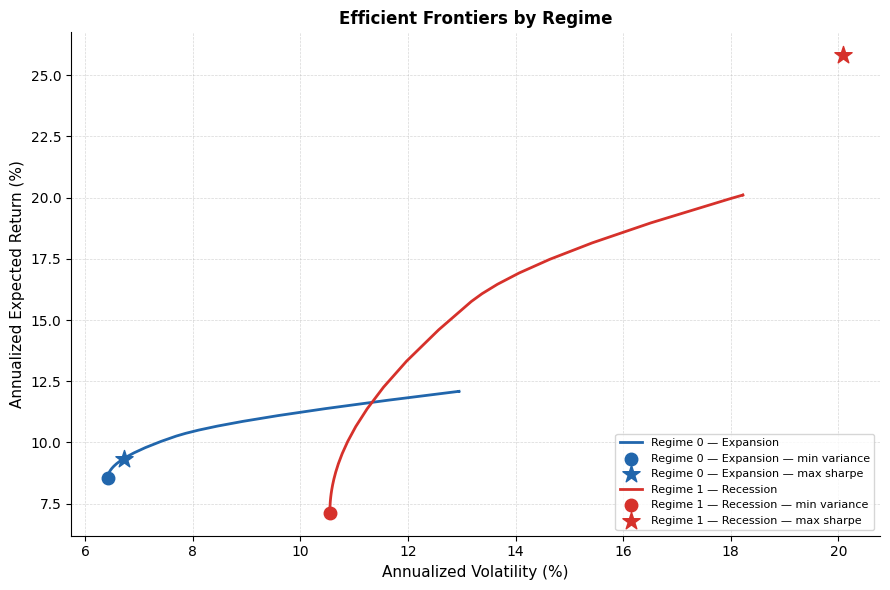


── Weights ready for backtest ──

Regime 0:
  Min variance : [0.3044 0.4486 0.247 ]
  Max Sharpe   : [0.4001 0.4701 0.1298]

Regime 1:
  Min variance : [0.3148 0.3306 0.3546]
  Max Sharpe   : [-0.373   0.9565  0.4165]


In [417]:
asset_names = market_train.columns[:-1]  # all columns except 'HMM State'

print("=" * 55)
print("Regime-Conditional MVO")
print("=" * 55)
results = optimize_regimes(moments, asset_names, rf=0.0, long_only=False)

print("\n" + "=" * 55)
print("Efficient Frontiers")
print("=" * 55)
plot_frontiers(moments, asset_names, results)

# ── How to access weights for backtesting ─────────────────
print("\n── Weights ready for backtest ──")
for k in [0, 1]:
    w_mv = results[k]['min_variance'].weights
    w_ms = results[k]['max_sharpe'].weights
    print(f"\nRegime {k}:")
    print(f"  Min variance : {np.round(w_mv, 4)}")
    print(f"  Max Sharpe   : {np.round(w_ms, 4)}")

In [418]:
results[0]['min_variance'].weights

array([0.30442694, 0.44860222, 0.24697084])

In [419]:
results[1]['min_variance'].weights

array([0.31475574, 0.33064784, 0.35459642])

In [420]:
for kk, vv in results.items():
    print(f"\nRegime {kk}:")
    for pp, res in vv.items():
        print(f"  {pp}: weights = {np.round(res.weights, 4)}")


Regime 0:
  min_variance: weights = [0.3044 0.4486 0.247 ]
  max_sharpe: weights = [0.4001 0.4701 0.1298]
  max_return: weights = [ 0.9644  0.5968 -0.5612]

Regime 1:
  min_variance: weights = [0.3148 0.3306 0.3546]
  max_sharpe: weights = [-0.373   0.9565  0.4165]
  max_return: weights = [-3.442   2.9882  1.4538]


In [421]:
results[0]['min_variance']

PortfolioResult(weights=array([0.30442694, 0.44860222, 0.24697084]), exp_return=np.float64(0.007112938415150158), volatility=np.float64(0.018541229473934794), sharpe=np.float64(0.38362819602386705), regime=np.int64(0), portfolio='min_variance', asset_names=Index(['Equity', 'Bonds', 'Gold'], dtype='str'))

### Backtesting

In [422]:
"""
Backtest — Regime-Conditional vs Static Strategies
====================================================
Compares three strategies on the test set:
  1. Dynamic HMM    — rebalance when regime changes (min-variance or max-Sharpe)
  2. Equal weight   — 1/3 each asset, rebalanced monthly
  3. 60/40          — 60% equity / 40% bond, rebalanced monthly

Performance metrics computed for each strategy:
  - Annualized return
  - Annualized volatility
  - Sharpe ratio
  - Maximum drawdown
  - VaR (Value at Risk) at 95% confidence
  - CVaR (Conditional VaR / Expected Shortfall) at 95%

Assumptions
-----------
- Returns are simple (not log) monthly returns.
- No transaction costs (can be added via the tc_bps parameter).
- Rebalancing is costless for static strategies.
- For the dynamic strategy, rebalancing occurs only when the inferred
  state changes — not every period.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# =============================================================================
# PERFORMANCE METRICS
# =============================================================================

def compute_metrics(returns: pd.Series, rf: float = 0.0,
                    freq: int = 12, confidence: float = 0.95) -> dict:
    """
    Compute key performance metrics from a return series.

    Parameters
    ----------
    returns    : pd.Series of periodic (e.g. monthly) simple returns
    rf         : risk-free rate per period (same frequency as returns)
    freq       : periods per year (12 for monthly, 252 for daily)
    confidence : VaR / CVaR confidence level (default 0.95)

    Returns
    -------
    dict of metrics (all annualized where applicable)

    METRIC DEFINITIONS
    ------------------

    Annualized Return:
      (1 + mean_monthly_return)^freq - 1
      Geometric compounding of the average periodic return.

    Annualized Volatility:
      std(returns) * sqrt(freq)
      Scales periodic std to annual under i.i.d. assumption.

    Sharpe Ratio:
      (ann_return - rf_annual) / ann_vol
      where rf_annual = (1 + rf)^freq - 1.
      Measures excess return per unit of total risk.

    Maximum Drawdown (MDD):
      MDD = min_t [ (cumulative wealth at t) / (peak wealth up to t) - 1 ]
      Largest peak-to-trough decline in cumulative wealth.
      Computed from the cumulative return series, not periodic returns.

    VaR at confidence level α:
      VaR_α = -quantile(returns, 1-α)
      The loss not exceeded with probability α.
      E.g. VaR_0.95 = 2% means there is a 5% chance of losing more than 2%
      in a given period. Reported as a positive number (loss convention).

    CVaR (Expected Shortfall) at confidence level α:
      CVaR_α = -E[r | r < -VaR_α]
      The expected loss given that the loss exceeds VaR_α.
      Always >= VaR_α. More sensitive to tail risk than VaR.
      Also reported as a positive number.
    """
    r = returns.dropna().values
    T = len(r)

    # Annualized return (geometric)
    ann_ret = (1 + r.mean()) ** freq - 1

    # Annualized volatility
    ann_vol = r.std() * np.sqrt(freq)

    # Sharpe ratio
    rf_ann  = (1 + rf) ** freq - 1
    sharpe  = (ann_ret - rf_ann) / ann_vol if ann_vol > 1e-12 else 0.0

    # Maximum drawdown
    cum_wealth = (1 + r).cumprod()
    rolling_max = np.maximum.accumulate(cum_wealth)
    drawdowns   = cum_wealth / rolling_max - 1        # negative values
    max_dd      = drawdowns.min()                     # most negative

    # VaR and CVaR at confidence level
    alpha    = 1 - confidence
    var_threshold = np.quantile(r, alpha)             # negative value
    var      = -var_threshold                         # reported as positive loss
    cvar     = -r[r <= var_threshold].mean()          # expected loss in tail

    return {
        'Ann. Return (%)':     ann_ret  * 100,
        'Ann. Volatility (%)': ann_vol  * 100,
        'Sharpe Ratio':        sharpe,
        'Max Drawdown (%)':    max_dd   * 100,
        f'VaR {int(confidence*100)}% (%)':   var  * 100,
        f'CVaR {int(confidence*100)}% (%)':  cvar * 100,
    }


# =============================================================================
# STRATEGY RETURN SERIES
# =============================================================================

def dynamic_strategy_returns(df_test, asset_cols, state_col,
                              regime_weights: dict,
                              tc_bps: float = 0.0) -> pd.Series:
    """
    Compute period-by-period returns for the dynamic HMM strategy.

    REBALANCING LOGIC:
    At each period t, the portfolio holds weights w^{s_t} where s_t is the
    inferred state. Rebalancing occurs only when s_t ≠ s_{t-1}, i.e. when
    the regime changes. Between regime changes, the portfolio drifts with
    asset returns (buy-and-hold within regime).

    Note: we use the state inferred at the START of period t to determine
    weights, then apply the return realized DURING period t. This avoids
    look-ahead bias — we are not using s_t to trade on the return of period t
    after observing it.

    TRANSACTION COSTS:
    When a rebalance occurs, a flat cost of tc_bps basis points is deducted
    from the period return. With tc_bps=0 (default) this is ignored.

    Parameters
    ----------
    df_test        : pd.DataFrame — test set with asset returns and state column
    asset_cols     : list of str
    state_col      : str
    regime_weights : dict {k: np.ndarray (n,)} — frozen weights from training
    tc_bps         : transaction cost in basis points per rebalance event

    Returns
    -------
    pd.Series of portfolio returns, same index as df_test
    """
    returns = df_test[asset_cols].values     # (T_test, n)
    states  = df_test[state_col].values      # (T_test,)
    T       = len(states)

    port_rets = np.zeros(T)
    tc_cost   = tc_bps / 10_000

    prev_state = states[0]

    for t in range(T):
        s = states[t]
        w = regime_weights[s]                # frozen weights for this regime

        # Portfolio return: w^T r_t
        port_rets[t] = w @ returns[t]

        # Deduct transaction cost if regime changed
        if t > 0 and s != prev_state:
            port_rets[t] -= tc_cost

        prev_state = s

    return pd.Series(port_rets, index=df_test.index, name='HMM Dynamic')


def static_strategy_returns(df_test, asset_cols,
                             weights: np.ndarray,
                             name: str) -> pd.Series:
    """
    Compute period-by-period returns for a static (fixed-weight) strategy.

    Static strategies rebalance back to fixed weights every period.
    Portfolio return at t: w^T r_t (same weights every period).

    Parameters
    ----------
    df_test    : pd.DataFrame
    asset_cols : list of str
    weights    : (n,) fixed weight vector
    name       : strategy label

    Returns
    -------
    pd.Series of portfolio returns
    """
    returns = df_test[asset_cols].values     # (T_test, n)
    port_rets = returns @ weights            # (T_test,)
    return pd.Series(port_rets, index=df_test.index, name=name)


# =============================================================================
# FULL BACKTEST
# =============================================================================

def run_backtest(df_test, asset_cols, state_col,
                 regime_weights: dict,
                 equity_col: str,
                 bond_col:   str,
                 rf: float = 0.0,
                 freq: int = 12,
                 confidence: float = 0.95,
                 tc_bps: float = 0.0,
                 strategy_label: str = 'HMM Dynamic') -> dict:
    """
    Run backtest for all strategies and compute performance metrics.

    Parameters
    ----------
    df_test        : pd.DataFrame — test set
    asset_cols     : list of str — all asset columns (order must match weights)
    state_col      : str — inferred state column
    regime_weights : dict {k: np.ndarray} — from portfolio_optimization
    equity_col     : str — name of equity column (for 60/40)
    bond_col       : str — name of bond column   (for 60/40)
    rf             : float — risk-free rate per period
    freq           : int — periods per year
    confidence     : float — VaR/CVaR confidence level
    tc_bps         : float — transaction cost in bps for dynamic strategy
    strategy_label : str  — label for the dynamic strategy

    Returns
    -------
    dict with keys:
      'returns'     : pd.DataFrame — period returns for all strategies
      'cum_returns' : pd.DataFrame — cumulative wealth (start = 1)
      'metrics'     : pd.DataFrame — performance metrics table
    """
    n = len(asset_cols)
    equity_col = equity_col
    bond_col   = bond_col

    # ── Build weight vectors for static strategies ─────────────────────

    # Equal weight: 1/n each asset
    w_ew = np.ones(n) / n

    # 60/40: 60% equity, 40% bond, 0% everything else
    w_6040 = np.zeros(n)
    w_6040[asset_cols.index(equity_col)] = 0.60
    w_6040[asset_cols.index(bond_col)]   = 0.40

    # ── Compute return series ───────────────────────────────────────────
    r_dynamic = dynamic_strategy_returns(
        df_test, asset_cols, state_col, regime_weights, tc_bps=tc_bps
    )
    r_dynamic.name = strategy_label

    r_ew   = static_strategy_returns(df_test, asset_cols, w_ew,   'Equal Weight (1/n)')
    r_6040 = static_strategy_returns(df_test, asset_cols, w_6040, '60/40')

    all_returns = pd.concat([r_dynamic, r_ew, r_6040], axis=1)

    # ── Cumulative wealth (starting from 1) ────────────────────────────
    cum_returns = (1 + all_returns).cumprod()

    # ── Performance metrics ────────────────────────────────────────────
    metrics = {}
    for col in all_returns.columns:
        metrics[col] = compute_metrics(
            all_returns[col], rf=rf, freq=freq, confidence=confidence
        )
    metrics_df = pd.DataFrame(metrics).T   # strategies as rows, metrics as cols

    return {
        'returns':     all_returns,
        'cum_returns': cum_returns,
        'metrics':     metrics_df,
    }


# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_backtest(backtest: dict, state_series: pd.Series = None):
    """
    Four-panel backtest dashboard:
      1. Cumulative wealth
      2. Rolling 12-month Sharpe ratio
      3. Drawdown
      4. Monthly return distribution (box plot)

    Parameters
    ----------
    backtest     : dict returned by run_backtest()
    state_series : pd.Series of {0,1} states (optional) — shades recession periods
    """
    cum   = backtest['cum_returns']
    rets  = backtest['returns']

    colors = {'HMM Dynamic':         '#1a6faf',
              'Equal Weight (1/n)':  '#e07b00',
              '60/40':               '#444444'}
    # override with actual column names
    col_colors = {}
    for col in cum.columns:
        for key, c in colors.items():
            if key in col:
                col_colors[col] = c
                break
        if col not in col_colors:
            col_colors[col] = '#888888'

    fig = plt.figure(figsize=(14, 11))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

    ax1 = fig.add_subplot(gs[0, :])    # cumulative wealth — full width
    ax2 = fig.add_subplot(gs[1, 0])    # rolling Sharpe
    ax3 = fig.add_subplot(gs[1, 1])    # drawdown
    ax4 = fig.add_subplot(gs[2, :])    # return distribution — full width

    # ── Panel 1: Cumulative wealth ─────────────────────────────────────
    for col in cum.columns:
        ax1.plot(cum.index, cum[col], label=col,
                 color=col_colors[col], lw=1.8)

    if state_series is not None:
        _shade_recessions(ax1, state_series)

    ax1.set_title('Cumulative Wealth  (start = 1)', fontweight='bold')
    ax1.set_ylabel('Portfolio Value')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.axhline(1, color='gray', lw=0.7, ls='--')
    _style_ax(ax1)

    # ── Panel 2: Rolling 12-month Sharpe ──────────────────────────────
    window = 12
    for col in rets.columns:
        roll_mean = rets[col].rolling(window).mean()
        roll_std  = rets[col].rolling(window).std()
        roll_sh   = (roll_mean / roll_std.clip(1e-12)) * np.sqrt(window)
        ax2.plot(rets.index, roll_sh, label=col,
                 color=col_colors[col], lw=1.4)

    ax2.axhline(0, color='gray', lw=0.7, ls='--')
    ax2.set_title(f'Rolling {window}-Month Sharpe', fontweight='bold')
    ax2.set_ylabel('Sharpe Ratio')
    _style_ax(ax2)

    # ── Panel 3: Drawdown ─────────────────────────────────────────────
    for col in cum.columns:
        roll_max = cum[col].expanding().max()
        dd = (cum[col] / roll_max - 1) * 100
        ax3.fill_between(cum.index, dd, 0,
                         color=col_colors[col], alpha=0.35, label=col)
        ax3.plot(cum.index, dd, color=col_colors[col], lw=0.8)

    ax3.set_title('Drawdown (%)', fontweight='bold')
    ax3.set_ylabel('Drawdown (%)')
    _style_ax(ax3)

    # ── Panel 4: Return distribution ──────────────────────────────────
    data_bp   = [rets[col].dropna().values * 100 for col in rets.columns]
    bp = ax4.boxplot(data_bp, patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', lw=2))
    for patch, col in zip(bp['boxes'], rets.columns):
        patch.set_facecolor(col_colors[col])
        patch.set_alpha(0.7)

    ax4.set_xticklabels(rets.columns, fontsize=9)
    ax4.axhline(0, color='gray', lw=0.7, ls='--')
    ax4.set_title('Monthly Return Distribution (%)', fontweight='bold')
    ax4.set_ylabel('Return (%)')
    _style_ax(ax4)

    fig.suptitle('Backtest Results', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def print_metrics_table(metrics_df: pd.DataFrame):
    """Pretty-print the performance metrics table."""
    print("\n" + "=" * 70)
    print("PERFORMANCE METRICS")
    print("=" * 70)
    # Format each column appropriately
    fmt = metrics_df.copy()
    for col in fmt.columns:
        if 'Sharpe' in col:
            fmt[col] = fmt[col].map('{:.3f}'.format)
        else:
            fmt[col] = fmt[col].map('{:.2f}%'.format)
    print(fmt.to_string())
    print("=" * 70)


def _shade_recessions(ax, state_series):
    """Shade state-1 periods on an axes."""
    states = state_series.values
    dates  = state_series.index
    in_rec = False
    for i, s in enumerate(states):
        if s == 1 and not in_rec:
            start  = dates[i]
            in_rec = True
        elif s == 0 and in_rec:
            ax.axvspan(start, dates[i-1], color='#cccccc', alpha=0.4, zorder=0)
            in_rec = False
    if in_rec:
        ax.axvspan(start, dates[-1], color='#cccccc', alpha=0.4, zorder=0)


def _style_ax(ax):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
    ax.margins(x=0.01)




PERFORMANCE METRICS
                   Ann. Return (%) Ann. Volatility (%) Sharpe Ratio Max Drawdown (%) VaR 95% (%) CVaR 95% (%)
HMM Dynamic                 10.59%              10.07%        1.051          -21.95%       3.32%        5.20%
Equal Weight (1/n)          12.21%               9.60%        1.272          -19.61%       3.06%        4.84%
60/40                       10.23%              12.64%        0.809          -25.73%       5.12%        6.83%


C:\Users\mydam\AppData\Local\Temp\ipykernel_35188\1030976232.py:383: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


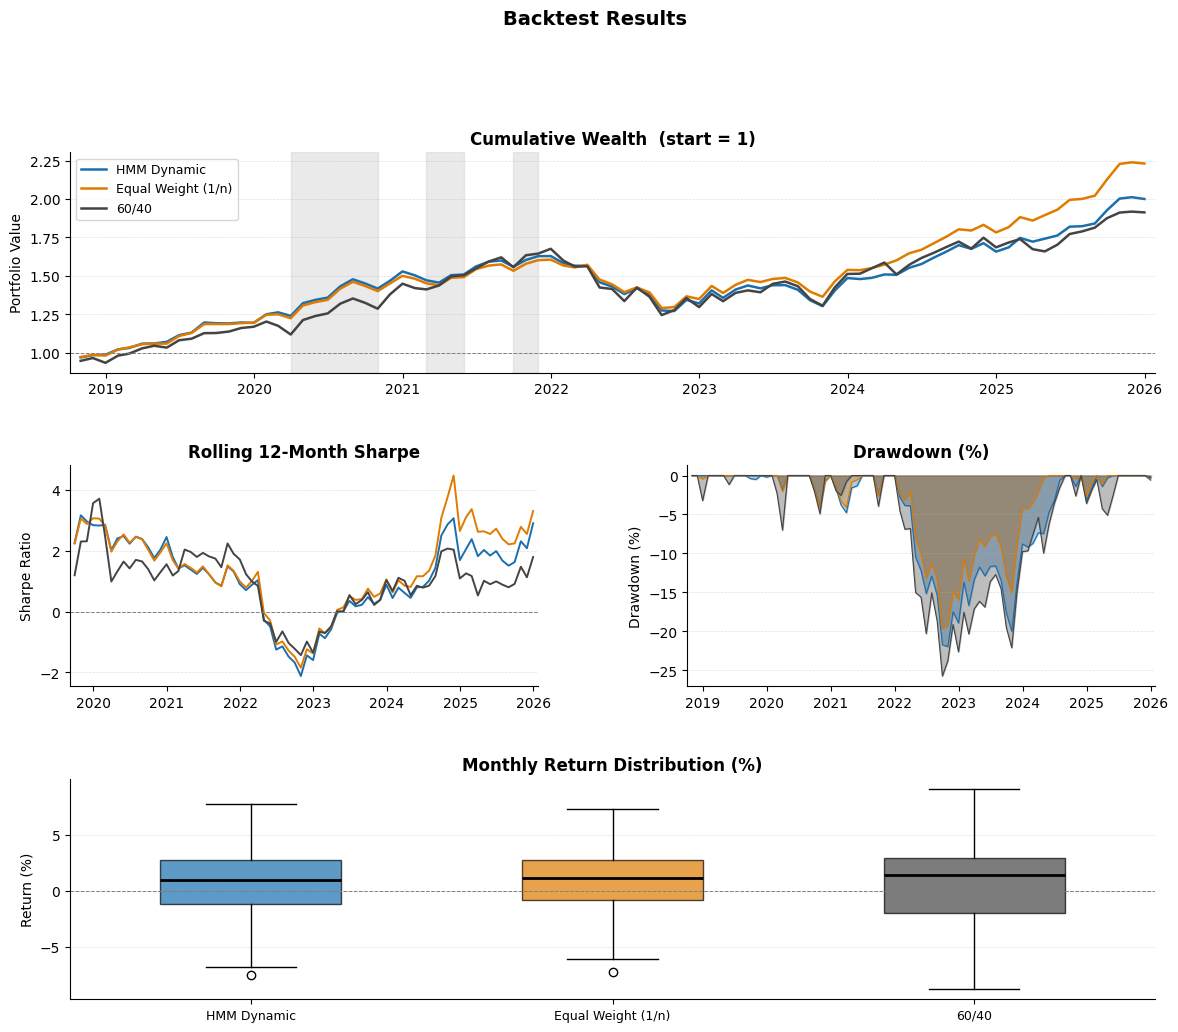

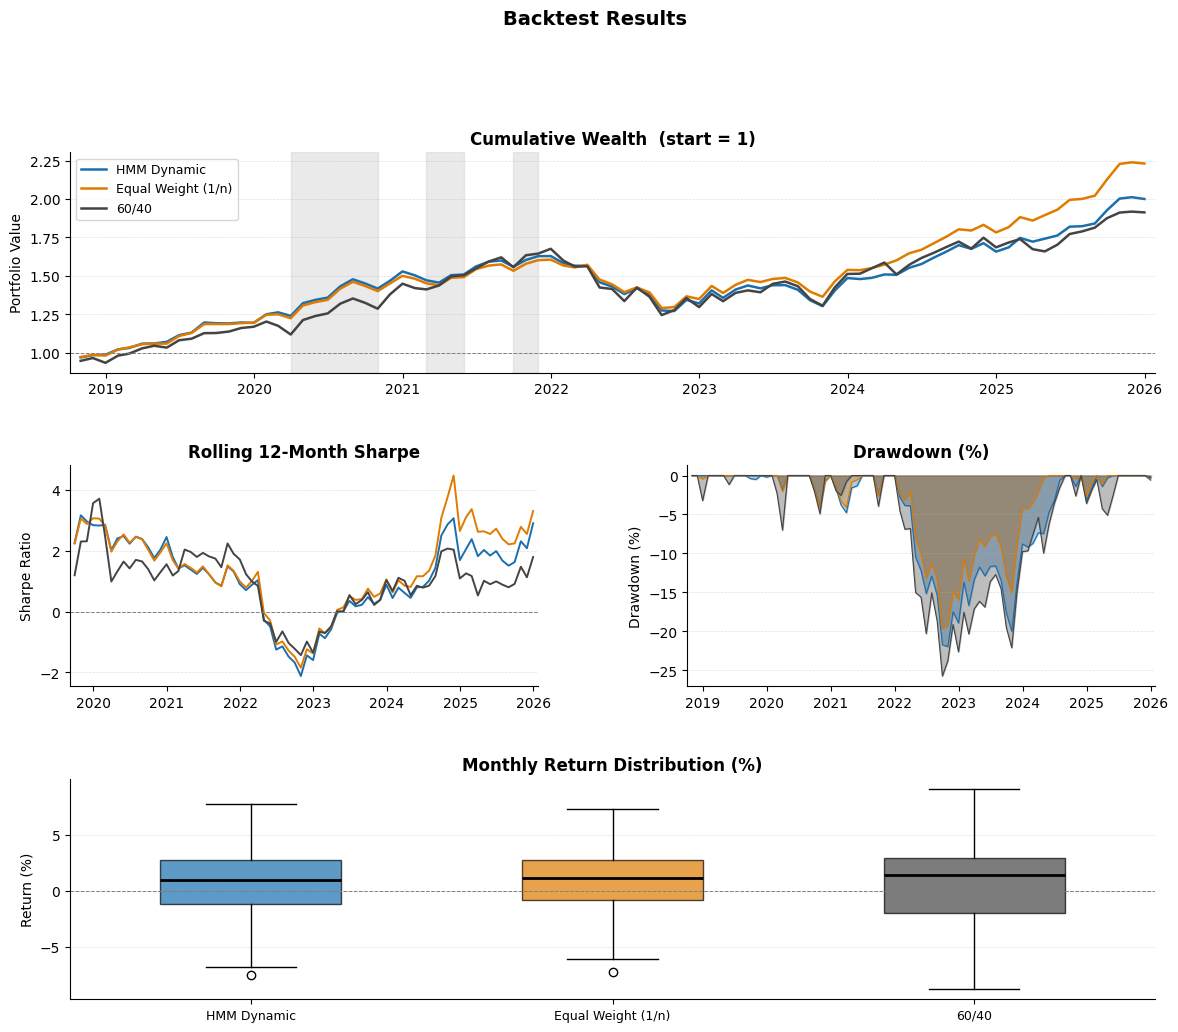

In [423]:

# =============================================================================
# RUN BACKTEST
# =============================================================================

regime_weights = {
    0: results[0]['min_variance'].weights,  # Regime 0: use min-variance weights
    1: results[1]['min_variance'].weights,  # Regime 1: use min-variance weights
}

backtest = run_backtest(
    df_test        = market_test,
    asset_cols     = market_test.columns[:-1].tolist(),  # all columns except 'HMM State'
    state_col      = 'HMM State',
    regime_weights = regime_weights,
    equity_col     = 'Equity',
    bond_col       = 'Bonds',
    rf             = 0.0,
    freq           = 12,
    confidence     = 0.95,
    tc_bps         = 0.0,
)

print_metrics_table(backtest['metrics'])
plot_backtest(backtest, state_series=market_test['HMM State'])

# ── Accessing outputs ──────────────────────────────────────────────
# backtest['returns']     — pd.DataFrame (T_test, 3) — period returns
# backtest['cum_returns'] — pd.DataFrame (T_test, 3) — cumulative wealth
# backtest['metrics']     — pd.DataFrame (3, 6)      — metrics table